## Module_3

## Team Members:
Isabella Imburgia and Isabella Orlando

## Project Title: Interpolating Lung Fibrosis in Mouse Models




## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## Disease Background: 
*Fill in information and please note that this module is truncated and only has 5 bullets (instead of the 11 that you did for Module #1).* DO MORE THAN 5 FOR FULL CREDIT

* Prevalence & incidence
* Risk factors (genetic, lifestyle)
* Symptoms
* Standard of care treatment(s)
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)

## Data-Set: 
*Describe the data set(s) you will analyze. Cite the source(s) of the data -- in this case, these data have not yet been published and they are "hot off the press", having been recently generated by the Peirce-Cottler Lab in collaboration with the Kim Lab (https://uvahealth.com/findadoctor/John-Kim-1407155682) in the Division of Pulmonary and Critical Care at UVA. So the proper way to cite these data is:

"Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 

Also, since we covered this in Lecture 1 of this Module in detail, describe how the data was collected -- What techniques were used? What units are the data measured in? Etc.*

## Data Analyis: 
*Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this Jupyter notebook can run your code to perform the analysis that you did, generate your figures, generate your .csv file, etc.). Show your graphs here, which should have proper labeles (e.g., x- and y-axes labels). Each graph you present should be thoroughly described by a caption so reader understands the data, why you are presenting it, and the main conclusion fromt the data.*

### Step 1: Load Images and Calculate % White Pixels

In [7]:
from termcolor import colored
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd
import time

start = time.time()

# Load the images you want to analyze

filenames = [
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010023.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010159.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010093.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010118.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010140.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010157.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010134.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010146.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010023.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010159.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010093.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010118.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010140.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010157.jpg",
]

# Enter the depth of each image (in the same order that the images are listed above; you can find these in the .csv file provided to you which is tilted: "Filenames and Depths for Students")

depths = [
    100,
    860,
    9300,
    9900,
    8300,
    750,
    6600,
    2000,
]

# Make sure the lists match
if len(filenames) != len(depths):
    raise ValueError("The number of filenames does not match the number of depths.")
# Make the lists that will be used

images = []
white_counts = []
black_counts = []
white_percents = []

# Build the list of all the images you are analyzing

# For each filename in the list of filenames, load the image and add it to the list of images. If the image cannot be loaded, raise an error.
for filename in filenames:
    img = cv2.imread(filename, 0)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {filename}")
    images.append(img)

# For each image (until the end of the list of images), calculate the number of black and white pixels and make a list that contains this information for each filename.
start = time.time()
for x in range(len(filenames)):
    _, binary = cv2.threshold(images[x], 127, 255, cv2.THRESH_BINARY)
    
    white = np.count_nonzero(binary == 255)
    total = binary.size
    black = total - white
    white_percent = (white / total) * 100

# Calculate the percentage of pixels in each image that are white and make a list that contains these percentages for each filename
    white_counts.append(white)
    black_counts.append(black)
    white_percents.append(white_percent)
end = time.time()

print(f"Processing time (no I/O): {end - start:.6f} seconds")
# Print the number of white and black pixels in each image.

print(colored("Counts of pixel by color in each image", "yellow"))
for x in range(len(filenames)):
    print(colored(f"White pixels in image {x}: {white_counts[x]}", "white"))
    print(colored(f"Black pixels in image {x}: {black_counts[x]}", "red"))
    print()

# Print the filename (on one line in red font), and below that line print the percent white pixels and depth into the lung where the image was obtained

print(colored("Percent white px:", "yellow"))
for x in range(len(filenames)):
    print(colored(f'{filenames[x]}:', "red"))
    print(f'{white_percents[x]}% White | Depth: {depths[x]} microns')
    print()

'''Write your data to a .csv file'''

# Create a DataFrame that includes the filenames, depths, and percentage of white pixels
df = pd.DataFrame({
    'Filenames': filenames,
    'Depths': depths,
    'White percents': white_percents
})

# Write that DataFrame to a .csv file

df.to_csv('Percent_White_Pixels.csv', index=False)

print("The .csv file 'Percent_White_Pixels.csv' has been created.")


Processing time (no I/O): 0.039151 seconds
Counts of pixel by color in each image
White pixels in image 0: 37508
Black pixels in image 0: 4156796

White pixels in image 1: 59426
Black pixels in image 1: 4134878

White pixels in image 2: 168932
Black pixels in image 2: 4025372

White pixels in image 3: 237289
Black pixels in image 3: 3957015

White pixels in image 4: 139818
Black pixels in image 4: 4054486

White pixels in image 5: 56419
Black pixels in image 5: 4137885

White pixels in image 6: 91653
Black pixels in image 6: 4102651

White pixels in image 7: 62913
Black pixels in image 7: 4131391

Percent white px:
C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010023.jpg:
0.8942604064941406% White | Depth: 100 microns

C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010159.jpg:
1.4168262481689453% White | Depth: 860 microns

C:\Users\ajq2af\OneDriv

Using the provided images of mouse lungs taken at different depths, the percentage of white pixels present in the photos was calculated. This represents fibrotic lung tissue in the mouse model which was written to a csv file contaning the file name, depth, and percent lung firbrosis. 

### Step 2: Interpolate the data and plot it

The interpolated point using linear interpolation is at the x-coordinate 2000 and y-coordinate 1.4999628067016602.


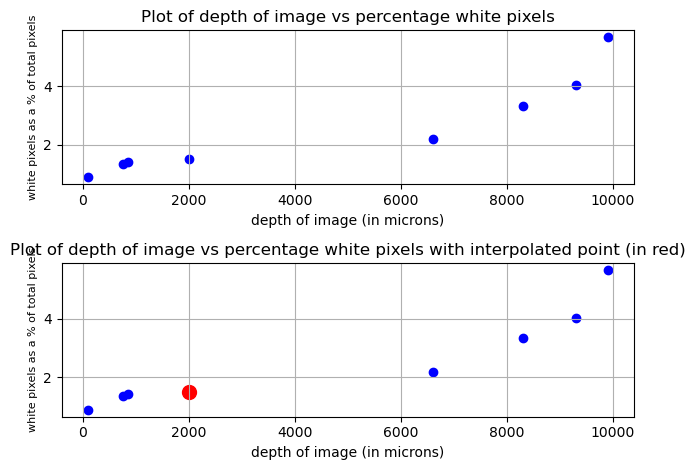

The interpolated point using quadratic interpolation is at the x-coordinate 2000 and y-coordinate 1.4999628067016602.


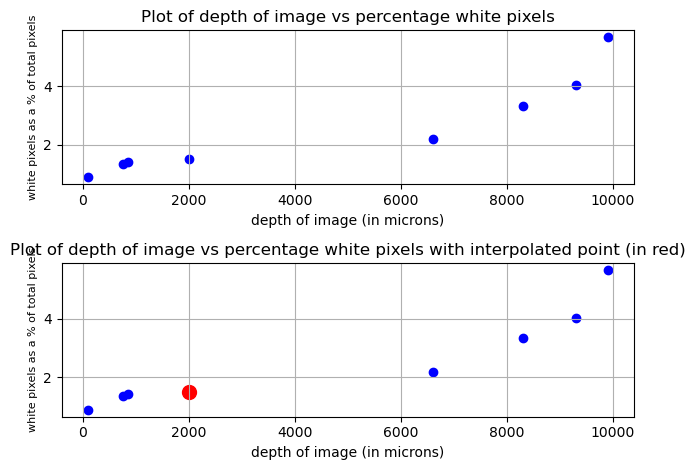

The interpolated point using cubic interpolation is at the x-coordinate 2000 and y-coordinate 1.4999628067016602.


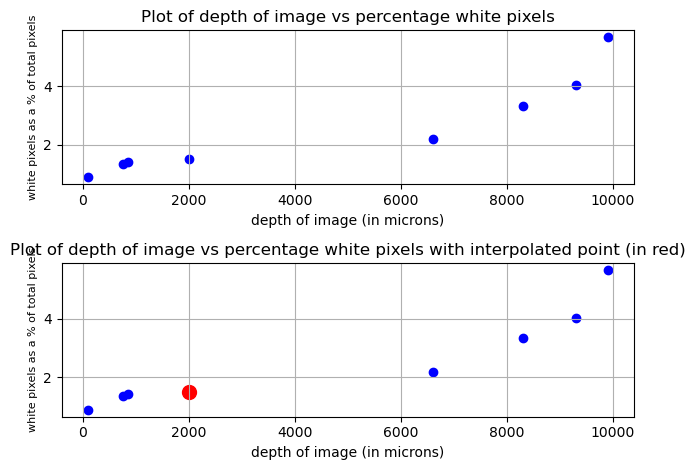

In [14]:
from termcolor import colored
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd
import time

interpolate_depth = 2000


x = depths
y = white_percents

# LINEAR INTERPOLATION
i = interp1d(x, y, kind='linear')
interpolate_point = i(interpolate_depth)
print(colored(
     f'The interpolated point using linear interpolation is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)


# # make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a % of total pixels', fontsize=8)
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o',
                linestyle='-', color='blue')
axs[1].set_title(
     'Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a % of total pixels', fontsize=8)
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
                color='red', s=100, label='Highlighted point')


# # Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# QUADRATIC INTERPOLATION
i = interp1d(x, y, kind='quadratic')
interpolate_point = i(interpolate_depth)
print(colored(
     f'The interpolated point using quadratic interpolation is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)


# # make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a % of total pixels', fontsize=8)
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o',
                linestyle='-', color='blue')
axs[1].set_title(
     'Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a % of total pixels', fontsize=8)
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
                color='red', s=100, label='Highlighted point')


# # Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# CUBIC INTERPOLATION
i = interp1d(x, y, kind='cubic')
interpolate_point = i(interpolate_depth)
print(colored(
     f'The interpolated point using cubic interpolation is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)


# # make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a % of total pixels', fontsize=8)
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o',
                linestyle='-', color='blue')
axs[1].set_title(
     'Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a % of total pixels', fontsize=8)
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
                color='red', s=100, label='Highlighted point')


# # Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

****change the code to be a specific depth and do different plots for linear, quadratic, and cubic 
compare with each type to the actual depth to do extra analysis 
**** do 2000 with linear, quad, cubic and for each one compare to the actual value, do percent error to find which is better and then use that to interpolate other data points

## Verify and validate your analysis: 
*Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., by comparing your analysis to a published paper).*

## Conclusions and Ethical Implications: 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

## References:
*You can use any format you like but provide the citations for facts that you referenced in this project notebook.*